# Neural Networks Progressive Lab
## One Neuron → Forward Pass → Backpropagation → MLP → Keras → Independent Task

Today you will connect the theory to code in a gradual way.

**Learning path**
1. Review the core equations.
2. Program the forward pass of one neuron from scratch.
3. Program the backward pass and update the parameters from scratch.
4. Extend the same logic to a small Multi-Layer Perceptron (MLP).
5. See how TensorFlow/Keras automates the same process.
6. Build and train an MLP independently.

> For the manual section we use **Sigmoid + MSE** because the derivatives are easy to follow. For practical binary classification with Keras, **Binary Cross-Entropy** is the usual loss.

# Part 0 — Core Equations

### Forward pass of one neuron
- Weighted sum: `z = w·x + b`
- Activation: `a = sigmoid(z)`
- Sigmoid: `sigmoid(z) = 1 / (1 + exp(-z))`

### Loss used in the manual section
- `L = (a - y)^2`

### Derivatives used in backpropagation
- `dL/da = 2(a-y)`
- `da/dz = a(1-a)`
- `dL/dz = (dL/da)(da/dz)`
- `dL/dw = (dL/dz)x`
- `dL/db = dL/dz`

### Gradient-descent update
- `parameter_new = parameter_old - learning_rate × gradient`

**Big picture:** Forward Pass → Loss → Backward Pass → Update

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fontTools.misc.cython import returns

np.set_printoptions(precision=4, suppress=True)

# Part 1 — One Neuron: Forward Pass From Scratch

Use one neuron with two inputs. The goal is to understand exactly what happens before moving to multiple neurons.

In [2]:
x = np.array([0.6, 0.8])
w = np.array([0.4, -0.2])
b = 0.1
y = 1.0

## Task 1.1 — Implement Sigmoid

In [3]:
def sigmoid(z):
    sigmoid = 1 / (1 + np.exp(-z))
    return sigmoid

## Task 1.2 — Implement the Forward Pass
Compute `z`, then apply Sigmoid to obtain `a`. Return both values.

In [4]:
def forward_single(x, w, b):
    # weighted sum
    z = np.dot(x, w) + b

    # activation
    a = sigmoid(z)
    return z, a

In [5]:
z, a = forward_single(x, w, b)
print("z =", z)
print("prediction a =", a)

z = 0.17999999999999997
prediction a = 0.5448788923735801


### Checkpoint
1. What is the difference between `z` and `a`?
* `z` is the raw weighted sum (w * x + b), while `a` is `z` passed through an activation function (sigmoid function here).

2. Which values are learnable parameters?
* `w` and `b` only.

# Part 2 — One Neuron: Backward Pass From Scratch

Now calculate how the loss changes with respect to the weights and bias.

In [6]:
def mse_loss(a, y):
    loss = (a - y) ** 2
    return loss

In [7]:
loss = mse_loss(a, y)
print("Loss =", loss)

Loss = 0.20713522260709927


## Task 2.1 — Compute Gradients
Use the chain rule:
`dL/da → da/dz → dL/dz → dW and db`

In [8]:
def backward_single(x, y, a):
    dL_da = 2 * (a - y)
    da_dz = a * (1 - a)
    dL_dz = dL_da * da_dz
    dW = dL_dz * x
    db = dL_dz
    return dW, db

In [9]:
dW, db = backward_single(x, y, a)
print("dW =", dW)
print("db =", db)

dW = [-0.1354 -0.1806]
db = -0.22572722133142242


## Task 2.2 — Update the Parameters

In [10]:
learning_rate = 0.1
w_new = w - learning_rate * dW
b_new = b - learning_rate * db
print("Old w:", w, " New w:", w_new)
print("Old b:", b, " New b:", b_new)

Old w: [ 0.4 -0.2]  New w: [ 0.4135 -0.1819]
Old b: 0.1  New b: 0.12257272213314224


## Task 2.3 — Did the Update Reduce the Loss?

In [11]:
# run another forward pass with the updated parameters
z_new, a_new = forward_single(x, w_new, b_new)
new_loss = mse_loss(a_new, y)
print("Old loss:", loss)
print("New loss:", new_loss)

Old loss: 0.20713522260709927
New loss: 0.1970917845381016


# Part 3 — From One Neuron to a Multi-Layer Perceptron

Architecture: **2 inputs → 2 hidden neurons → 1 output neuron**

The logic is exactly the same; we now repeat it across layers.

In [12]:
x = np.array([1.0, 0.0])
y = 1.0
W1 = np.array([[0.1, 0.3],[0.2, 0.4]])
b1 = np.array([0.1, 0.1])
W2 = np.array([[0.5],[0.6]])
b2 = np.array([0.1])

## Task 3.1 — MLP Forward Pass From Scratch
Compute hidden `z1`, hidden activation `a1`, output `z2`, then `y_hat`.

In [13]:
def forward_mlp(x, W1, b1, W2, b2):
    z1 = np.dot(x, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    y_hat = sigmoid(z2)
    cache = {"x":x,"a1":a1,"y_hat":y_hat}
    return y_hat, cache

In [14]:
y_hat, cache = forward_mlp(x, W1, b1, W2, b2)
print("Hidden activation:", cache["a1"])
print("Prediction:", y_hat)

Hidden activation: [0.5498 0.5987]
Prediction: [0.6757]


## Task 3.2 — MLP Backward Pass From Scratch

**Output layer**
- `delta2 = 2(y_hat-y) × y_hat(1-y_hat)`
- `dW2 = a1 × delta2`
- `db2 = delta2`

**Hidden layer**
- Send the output error backward through `W2`
- Multiply by the hidden sigmoid derivative
- Compute `dW1` and `db1`

In [15]:
def backward_mlp(y, cache, W2):
    x = cache["x"]
    a1 = cache["a1"]
    y_hat = cache["y_hat"]

    delta2 = 2 * (y_hat - y) * y_hat * (1 - y_hat)
    dW2 = np.outer(a1, delta2)
    db2 = delta2

    da1 = np.dot(W2, delta2)
    delta1 = da1 * a1 * (1 - a1)
    dW1 = np.outer(x, delta1)
    db1 = delta1

    return dW1, db1, dW2, db2

In [16]:
dW1, db1, dW2, db2 = backward_mlp(y, cache, W2)
print("dW1:", dW1)
print("db1:", db1)
print("dW2:", dW2)
print("db2:", db2)

dW1: [[-0.0176 -0.0205]
 [-0.     -0.    ]]
db1: [-0.0176 -0.0205]
dW2: [[-0.0781]
 [-0.0851]]
db2: [-0.1421]


### Explain before moving on
1. Why does backpropagation start from the output?
* the error is only known at the output. so we start there, and work backwards.

2. What does a gradient tell us?
* the direction and size of the change needed to reduce the loss.

3. Why does the hidden layer receive its error from the next layer?
* the hidden layer has no target of its own, so its error comes from the output error sent back through `W2`

# Part 4 — The Same Idea with TensorFlow / Keras

Keras automates the matrix operations, forward propagation, loss calculation, automatic differentiation, backpropagation, and parameter updates.

In [17]:
import tensorflow as tf
tf.random.set_seed(42)
print(tf.__version__)

2026-08-19 20:02:31.195978: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.16.2


In [18]:
X_train = np.array([[0.10,0.20],[0.20,0.30],[0.30,0.25],[0.40,0.35],[0.55,0.60],[0.65,0.70],[0.75,0.65],[0.85,0.90]], dtype=np.float32)
y_train = np.array([0,0,0,0,1,1,1,1], dtype=np.float32)

## Guided Keras Example
Architecture: **2 inputs → 3 hidden neurons → 1 output neuron**

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(3, activation="sigmoid"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(X_train, y_train, epochs=300, verbose=0)
loss_value, accuracy = model.evaluate(X_train, y_train, verbose=0)
print("Loss:", round(loss_value,4))
print("Accuracy:", round(accuracy,4))

Loss: 0.6134
Accuracy: 1.0


### Connect the code to the theory
- `Dense(...)` performs the weighted sums and activations.
- `loss=...` defines how error is measured.
- TensorFlow computes gradients automatically.
- The optimizer updates the parameters.
- `model.fit()` repeats the training loop across epochs.

# Part 5 — Independent Student Task

Build your own MLP for a non-linear binary classification dataset.

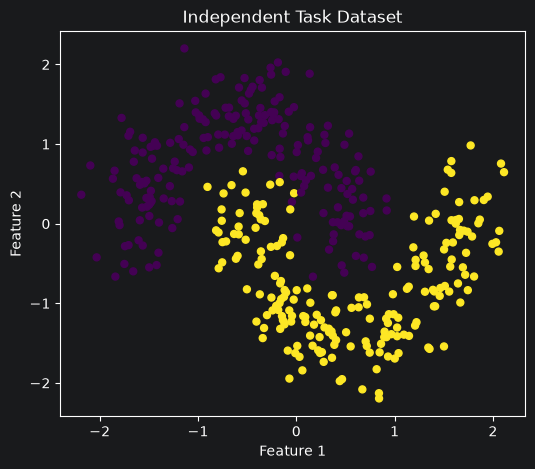

In [22]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_task, y_task = make_moons(n_samples=500, noise=0.18, random_state=42)
X_train_task, X_test_task, y_train_task, y_test_task = train_test_split(
    X_task, y_task, test_size=0.2, random_state=42, stratify=y_task
)
scaler = StandardScaler()
X_train_task = scaler.fit_transform(X_train_task)
X_test_task = scaler.transform(X_test_task)

plt.figure(figsize=(6,5))
plt.scatter(X_train_task[:,0], X_train_task[:,1], c=y_train_task, s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Independent Task Dataset")
plt.show()

## Requirements
Build a Keras model with:
- Input: 2 features
- Hidden Layer 1: 8 neurons, ReLU
- Hidden Layer 2: 4 neurons, ReLU
- Output: 1 neuron, Sigmoid

Then:
1. Print `model.summary()`
2. Compile with Adam + Binary Cross-Entropy + Accuracy
3. Train with a validation split
4. Plot training and validation loss
5. Evaluate on the test set
6. Generate probabilities and class predictions
7. Answer the reflection questions

In [30]:
# 1: Build the model
student_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
student_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
# 2: Compile the model
student_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [32]:
# Train the model with validation data
history = student_model.fit(
    X_train_task, y_train_task,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    verbose=0
)

print("Final train accuracy:", round(history.history["accuracy"][-1], 4))
print("Final validation accuracy:", round(history.history["val_accuracy"][-1], 4))

Final train accuracy: 0.9875
Final validation accuracy: 0.9875


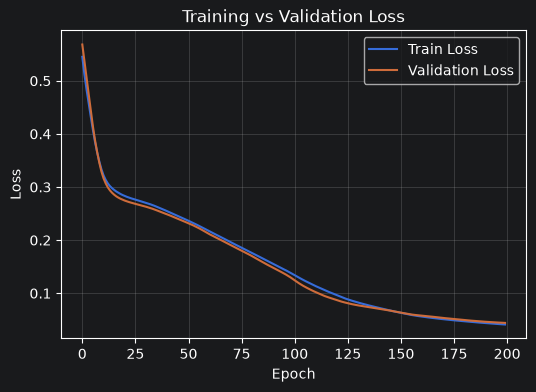

In [33]:
# Plot training and validation loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [34]:
# 5: Evaluate on the test set
test_loss, test_accuracy = student_model.evaluate(X_test_task, y_test_task, verbose=0)
train_loss, train_accuracy = student_model.evaluate(X_train_task, y_train_task, verbose=0)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("Train accuracy:", round(train_accuracy, 4))

Test loss: 0.0283
Test accuracy: 0.99
Train accuracy: 0.99


In [35]:
# 6: Generate probabilities and convert them to 0/1 predictions
probabilities = student_model.predict(X_test_task, verbose=0).ravel()
predictions = (probabilities > 0.5).astype(int)

print("First 5 probabilities:", np.round(probabilities[:5], 4))
print("First 5 predictions: ", predictions[:5])
print("First 5 actual:      ", y_test_task[:5])
print("Correct:", (predictions == y_test_task).sum(), "/", len(y_test_task))

First 5 probabilities: [0.9994 0.0004 0.0229 1.     0.9982]
First 5 predictions:  [1 0 0 1 1]
First 5 actual:       [1 0 0 1 1]
Correct: 99 / 100


## Reflection Questions
1. What does the forward pass compute?
* the prediction. inputs go through each layer as z = w·x + b then an activation, until the output layer gives y_hat.

2. What does the loss measure?
* how far the prediction is from the true label. one number saying how wrong the model is.

3. What happens during backpropagation?
* the error at the output is sent backwards through the network using the chain rule, giving a gradient for every weight and bias.

4. What does the optimizer do?
* it uses those gradients to update the parameters, new = old - learning_rate * gradient. the gradient says which direction, the learning rate says how big a step.

5. What do hidden layers add compared with one neuron?
* one neuron can only draw a straight line. hidden layers stack and bend those lines, so the model can separate data that is not linearly separable, like the two moons here.

6. What does `model.fit()` automate?
* the whole loop. forward pass, loss, gradients, updates, repeated over every batch and every epoch, plus tracking metrics and validation.

7. Why is Sigmoid used in the output layer?
* it squashes the output to between 0 and 1, so it reads as a probability for a binary label. anything above 0.5 becomes class 1.

8. Why are ReLU activations used in the hidden layers?
* relu is just max(0, z), so it is fast and its gradient is 1 for positive values. sigmoid gradients get tiny when z is large or small, which slows down or stops learning in deeper layers.

# Final Summary
**One neuron:** Inputs → Weighted Sum → Activation → Prediction

**Learning step:** Forward Pass → Loss → Backward Pass → Update

**MLP:** Input → Hidden Representations → Output

**Keras:** The same mathematics, automated by a deep-learning framework.